In [145]:
import dataclasses
import glob
import itertools
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import seaborn as sns

from lib.plots import faint_color, reverse_legend, set_axis
from lib.stats import fit_power_law

In [146]:
task_ids = [
    "0-no_loops",
    "1-static_loops",
    "2-static_loops_crossable",
    "3-loop_extrusion",
    "4-loop_extrusion_slow",
    "5-loop_capture",
    "6-loop_capture_transient",
    "7-static_loops_bounded",
    "8-static_loops_bounded_crossable",
    "9-loop_capture_persistent",
    "10-loop_capture_transient",
    "11-loop_extrusion_slow",
    "12-loop_extrusion_fast",
]
config_count = 10

In [147]:
@dataclasses.dataclass
class TaskData:
    frame_duration: float
    msd: np.ndarray             # (replicates, lag)
    loop_coverage: np.ndarray   # (replicates)
    rg: np.ndarray              # (replicates)


phase_key = "production"
msd_lag_cutoff = 11


def load_task_data(task_id: str) -> TaskData:
    msd_ensemble = []
    cov_ensemble = []
    rg_ensemble = []

    for config_id in range(config_count):
        with h5py.File(f"{task_id}/_outputs/metrics-{config_id}.h5", "r") as store:
            config_used = json.loads(store["config_used"][()])
            site_msds = store["site_msds"][:, :msd_lag_cutoff, :]   # (replicates, lag, sites)
            if "loop_coverages_nonred" in store:
                loop_covs = store["loop_coverages_nonred"][:, :]    # (replicates, time)
            else:
                loop_covs = store["loop_coverages"][:, :]           # (replicates, time)
            chain_rgs = store["chain_rgs"][:, :]                    # (replicates, time)

            msd_ensemble.append(site_msds)
            cov_ensemble.append(loop_covs)
            rg_ensemble.append(chain_rgs)

    # All configs in the same task share the same sampling settings.
    # Take the last one.
    sampling_config = config_used["sampling"]
    phase_configs = {phase["name"]: phase for phase in sampling_config["phases"]}
    phase_config = {**sampling_config, **phase_configs[phase_key]}
    frame_duration = phase_config["timestep"] * phase_config["sampling_interval"]

    msd_ensemble = np.array(msd_ensemble)   # (configs, replicates, lag, sites)
    cov_ensemble = np.array(cov_ensemble)   # (configs, replicates, time)
    rg_ensemble = np.array(rg_ensemble)     # (configs, replicates, time)

    return TaskData(
        frame_duration=frame_duration,
        msd=msd_ensemble.mean(axis=(0, 3)),
        loop_coverage=cov_ensemble.mean(axis=(0, 2)),
        rg=rg_ensemble.mean(axis=(0, 2)),
    )


task_data = {
    task_id: load_task_data(task_id) for task_id in task_ids
}

In [206]:
@dataclasses.dataclass
class TaskEstimates:
    msd_mean: np.ndarray        # (lag)
    msd_stderr: np.ndarray      # (lag)
    msd_alpha: np.ndarray       # (replicates)
    msd_prefactor: np.ndarray   # (replicates)


def compute_task_estimates(data: TaskData) -> TaskEstimates:
    # Normalize lag time to the last value. This way the prefactor for the
    # power-law has the well-defined unit. The functional form is thus
    #   M(Δt) = prefactor * (Δt / τ0)^α
    # where τ0 is the largest lag time.
    x = np.linspace(0, 1, num=data.msd.shape[1])

    msd_alpha = []
    msd_prefactor = []
    for i in range(data.msd.shape[0]):
        y = data.msd[i, :]
        alpha, prefactor = fit_power_law(x, y)
        msd_alpha.append(alpha)
        msd_prefactor.append(prefactor)

    return TaskEstimates(
        msd_mean=np.mean(data.msd, axis=0),
        msd_stderr=np.std(data.msd, axis=0, ddof=1),
        msd_alpha=np.array(msd_alpha),
        msd_prefactor=np.array(msd_prefactor),
    )


task_estimates = {
    task_id: compute_task_estimates(data) for task_id, data in task_data.items()
}

In [207]:
@dataclasses.dataclass
class ConditionSpec:
    task_id: str
    color: any
    offset: float
    label: str
    style: str | None = None


color_del = "k"
color_ncSL = "#5fbcd3"
color_crSL = "#5f5fd3"
color_fLE = "#de8787"
color_sLE = "#c83737"
color_pLC = "#217844"
color_tLC = "#5fd38d"

conditions_name = "static_loops"
conditions = [
    ConditionSpec(task_id=task_ids[0], color=color_del, offset=0, label="Δcohesin"),
    ConditionSpec(task_id=task_ids[1], color=color_ncSL, offset=1, label="Non-crossable SL"),
    ConditionSpec(task_id=task_ids[2], color=color_crSL, offset=2, label="Crossable SL"),
]

#conditions_name = "dynamic_loops"
#conditions = [
#    ConditionSpec(task_id=task_ids[0], color=color_del, offset=0, label="Δcohesin"),
#    ConditionSpec(task_id=task_ids[10], color=color_tLC, offset=1, label="Transient LC"),
#    ConditionSpec(task_id=task_ids[9], color=color_pLC, offset=2, label="Persistent LC"),
#    ConditionSpec(task_id=task_ids[12], color=color_fLE, offset=3, label="Fast LE"),
#    ConditionSpec(task_id=task_ids[11], color=color_sLE, offset=4, label="Slow LE"),
#]

#conditions_name = "everything"
#conditions = [
#    ConditionSpec(task_id=task_ids[0], color=color_del, offset=0, label="Δcohesin"),
#    ConditionSpec(task_id=task_ids[10], color=color_tLC, offset=1, label="Transient LC"),
#    ConditionSpec(task_id=task_ids[9], color=color_pLC, offset=2, label="Persistent LC"),
#    ConditionSpec(task_id=task_ids[12], color=color_fLE, offset=3, label="Fast LE"),
#    ConditionSpec(task_id=task_ids[11], color=color_sLE, offset=4, label="Slow LE"),
#    ConditionSpec(task_id=task_ids[1], color=color_ncSL, offset=5, label="Non-crossable SL"),
#    ConditionSpec(task_id=task_ids[2], color=color_crSL, offset=6, label="Crossable SL"),
#]

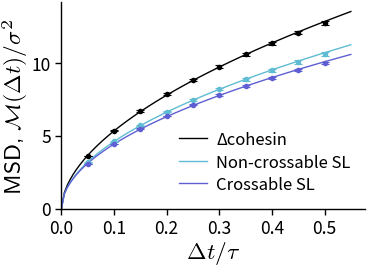

In [208]:
fig, ax = plt.subplots(figsize=(1.9, 1.4))

for condition in conditions:
    data = task_data[condition.task_id]
    estimates = task_estimates[condition.task_id]

    x = np.arange(len(estimates.msd_mean)) * data.frame_duration
    y = estimates.msd_mean
    y_err = estimates.msd_stderr
    ax.errorbar(
        x[1:],
        y[1:],
        y_err[1:],
        linestyle="none",
        color=condition.color,
        marker="o",
        markersize=1,
        elinewidth=0.4,
        capsize=1.3,
        capthick=0.4,
        zorder=2,
    )

    mean_alpha, mean_prefactor = fit_power_law(x, y)
    x = np.linspace(0, len(estimates.msd_mean) * data.frame_duration, num=100)
    y = x**mean_alpha * mean_prefactor
    ax.plot(x, y, color=condition.color, label=condition.label, zorder=1)

ax.legend()
ax.set_xlim(0, )
ax.set_ylim(0, )

ax.set_xticks(np.arange(0, 0.51, 0.1))
ax.set_xlabel(r"$ \Delta t / \tau $", usetex=True)
ax.set_ylabel(r"MSD, $ \mathcal{M}(\Delta t) / \sigma^2 $", usetex=True)

set_axis(ax, "left bottom")

fig.savefig(f"_figs/MSD_curve-{conditions_name}.svg")

pass

/home/sinfu/.local/share/miniconda3/envs/notebooks-cuda/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


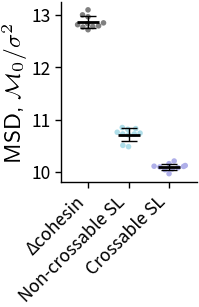

In [209]:
fig_width = 0.7 + len(conditions) * 0.12
fig_height = 1.6

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

swarm_data = {
    condition.label: task_estimates[condition.task_id].msd_prefactor
    for condition in conditions
}

sns.swarmplot(
    swarm_data,
    palette=[faint_color(condition.color) for condition in conditions],
    size=2,
    zorder=1,
    ax=ax,
)

swarm_means = [
    swarm_data[condition.label].mean()
    for condition in conditions
]
swarm_stderrs = [
    swarm_data[condition.label].std(ddof=1)
    for condition in conditions
]

ax.errorbar(
    np.arange(len(conditions)),
    swarm_means,
    swarm_stderrs,
    linestyle="none",
    marker="_",
    markersize=8,
    capsize=3,
    capthick=0.5,
    elinewidth=0.5,
    color="k",
    zorder=2,
)

for label_text in ax.get_xticklabels():
    label_text.set_rotation(45)
    label_text.set_horizontalalignment("right")

ax.set_ylabel(r"MSD, $ \mathcal{M}_0/\sigma^2 $", usetex=True)

ax.margins(0.2, 0.05)

set_axis(ax, "left bottom")

fig.savefig(f"_figs/MSD_reference-{conditions_name}.svg")

pass

In [210]:
for cond_i, cond_j in itertools.combinations(conditions, 2):
    t_test = scipy.stats.ttest_ind(
        task_data[cond_i.task_id].msd[:, -1],
        task_data[cond_j.task_id].msd[:, -1],
    )
    print("{:25s} {:25s} -- p={:.3g}".format(cond_i.task_id, cond_j.task_id, t_test.pvalue))

0-no_loops                1-static_loops            -- p=1.45e-18
0-no_loops                2-static_loops_crossable  -- p=3.29e-22
1-static_loops            2-static_loops_crossable  -- p=1.42e-10


In [211]:
for condition in conditions:
    a_m = task_estimates[condition.task_id].msd_alpha.mean()
    a_s = task_estimates[condition.task_id].msd_alpha.std(ddof=1)
    m_m = task_estimates[condition.task_id].msd_prefactor.mean()
    m_s = task_estimates[condition.task_id].msd_prefactor.std(ddof=1)
    print(
        f"{condition.label:16s}"
        + f"  M0 = {m_m:.1f} ± {m_s:.1g}"
        + f"  α = {a_m:.3f} ± {a_s:.1g}"
    )

Δcohesin          M0 = 12.9 ± 0.1  α = 0.545 ± 0.003
Non-crossable SL  M0 = 10.7 ± 0.1  α = 0.523 ± 0.003
Crossable SL      M0 = 10.1 ± 0.07  α = 0.510 ± 0.003


In [212]:
reference_index = None
for i, condition in enumerate(conditions):
    if condition.label == "Δcohesin":
        reference_index = i

if reference_index is not None:
    mref = task_estimates[conditions[reference_index].task_id].msd_prefactor.mean()
    for condition in conditions:
        m = task_estimates[condition.task_id].msd_prefactor.mean()
        f = m / mref
        print(f"{condition.label:16s}  fMSD = {f:.3f}")

Δcohesin          fMSD = 1.000
Non-crossable SL  fMSD = 0.833
Crossable SL      fMSD = 0.785


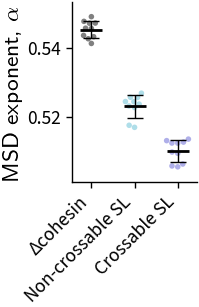

In [213]:
fig_width = 0.7 + len(conditions) * 0.12
fig_height = 1.6

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

swarm_data = {
    condition.label: task_estimates[condition.task_id].msd_alpha
    for condition in conditions
}

sns.swarmplot(
    swarm_data,
    palette=[faint_color(condition.color) for condition in conditions],
    size=2,
    zorder=1,
    ax=ax,
)

swarm_means = [
    swarm_data[condition.label].mean()
    for condition in conditions
]
swarm_stderrs = [
    swarm_data[condition.label].std(ddof=1)
    for condition in conditions
]

ax.errorbar(
    np.arange(len(conditions)),
    swarm_means,
    swarm_stderrs,
    linestyle="none",
    marker="_",
    markersize=8,
    capsize=3,
    capthick=0.5,
    elinewidth=0.5,
    color="k",
    zorder=2,
)

for label_text in ax.get_xticklabels():
    label_text.set_rotation(45)
    label_text.set_horizontalalignment("right")

ax.margins(0.15, 0.1)

ax.set_ylabel(r"MSD exponent, $ \alpha $", usetex=True)

set_axis(ax, "left bottom")

fig.savefig(f"_figs/MSD_alpha-{conditions_name}.svg")

pass

/home/sinfu/.local/share/miniconda3/envs/notebooks-cuda/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 30.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


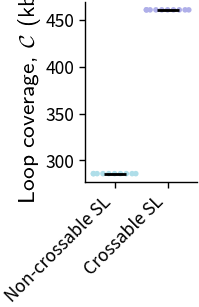

In [214]:
fig_width = 0.7 + len(conditions) * 0.12
fig_height = 1.6

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

swarm_data = {
    condition.label: task_data[condition.task_id].loop_coverage
    for condition in conditions[1:]
}
swarm_palette = [faint_color(condition.color) for condition in conditions[1:]]

sns.swarmplot(
    swarm_data,
    palette=swarm_palette,
    size=2,
    zorder=1,
    ax=ax,
)

swarm_means = [
    swarm_data[condition.label].mean()
    for condition in conditions[1:]
]
swarm_stderrs = [
    swarm_data[condition.label].std(ddof=1)
    for condition in conditions[1:]
]

ax.errorbar(
    np.arange(len(swarm_data)),
    swarm_means,
    swarm_stderrs,
    linestyle="none",
    marker="_",
    markersize=8,
    capsize=3,
    capthick=0.5,
    elinewidth=0.5,
    color="k",
    zorder=2,
)

for label_text in ax.get_xticklabels():
    label_text.set_rotation(45)
    label_text.set_horizontalalignment("right")

ax.margins(0.15, 0.05)
# ax.set_yscale("log")

ax.set_ylabel(r"Loop coverage, $ \mathcal{C} $ (kb)", usetex=True)

set_axis(ax, "left bottom")

fig.savefig(f"_figs/LoopCov-{conditions_name}.svg")

pass

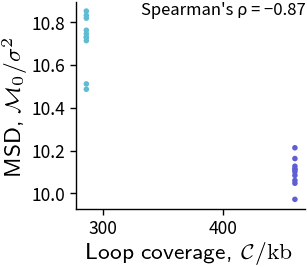

In [215]:
fig, ax = plt.subplots(figsize=(1.6, 1.4))

xs = []
ys = []

for condition in conditions[1:]:
    x = task_data[condition.task_id].loop_coverage
    y = task_estimates[condition.task_id].msd_prefactor
    ax.scatter(
        x,
        y,
        s=4,
        edgecolor="none",
        facecolor=condition.color,
        label=condition.label,
    )
    xs.extend(x)
    ys.extend(y)

spearman = scipy.stats.spearmanr(xs, ys)
s = "Spearman's ρ = " + "{:.2f}".format(spearman.statistic).replace("-", "−")
ax.text(1, 1, s, ha="right", va="top", fontsize="small", transform=ax.transAxes)

# ax.set_xscale("log")

# ax.legend(loc="lower left")
ax.set_xlabel(r"Loop coverage, $ \mathcal{C}/\mathrm{kb} $", usetex=True)
ax.set_ylabel(r"MSD, $ \mathcal{M}_0/\sigma^2 $", usetex=True)

set_axis(ax, "left bottom")

fig.savefig(f"_figs/LoopCov_MSD_correlation-{conditions_name}.svg")

pass

/home/sinfu/.local/share/miniconda3/envs/notebooks-cuda/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


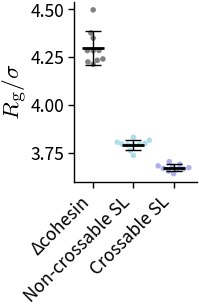

In [216]:
fig_width = 0.7 + len(conditions) * 0.12
fig_height = 1.6

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

swarm_data = {
    condition.label: task_data[condition.task_id].rg
    for condition in conditions
}
swarm_palette = [faint_color(condition.color) for condition in conditions]

sns.swarmplot(
    swarm_data,
    palette=swarm_palette,
    size=2,
    zorder=1,
    ax=ax,
)

swarm_means = [
    swarm_data[condition.label].mean()
    for condition in conditions
]
swarm_stderrs = [
    swarm_data[condition.label].std(ddof=1)
    for condition in conditions
]

ax.errorbar(
    np.arange(len(swarm_data)),
    swarm_means,
    swarm_stderrs,
    linestyle="none",
    marker="_",
    markersize=8,
    capsize=3,
    capthick=0.5,
    elinewidth=0.5,
    color="k",
    zorder=2,
)

for label_text in ax.get_xticklabels():
    label_text.set_rotation(45)
    label_text.set_horizontalalignment("right")

ax.margins(0.15, 0.05)
# ax.set_yscale("log")

ax.set_ylabel(r"$ R_\mathrm{g} / \sigma $", usetex=True)

set_axis(ax, "left bottom")

fig.savefig(f"_figs/Rg-{conditions_name}.svg")

pass